# Disease Outbreak Early Warning System

## Notebook 06: Model Evaluation and Performance Analysis

### Purpose

Forecasting models must be evaluated to determine their accuracy and reliability.

This notebook compares forecasting approaches using standard statistical performance metrics and identifies the most effective model for dengue incidence prediction.

### Objectives

- Evaluate forecasting performance
- Compute MAE
- Compute RMSE
- Compute MAPE
- Compare forecasting models
- Select the best-performing model

### Expected Outcome

A quantitative assessment of forecasting accuracy and a clear justification for model selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Loading and Preparing Data

The dengue surveillance data are reconstructed and converted into a weekly disease incidence time series.

In [2]:
features = pd.read_csv(
    "/content/dengue_features_train.csv"
)

labels = pd.read_csv(
    "/content/dengue_labels_train.csv"
)

dengue_df = pd.merge(
    features,
    labels,
    on=[
        "city",
        "year",
        "weekofyear"
    ]
)

dengue_df["week_start_date"] = pd.to_datetime(
    dengue_df["week_start_date"]
)

time_series = (
    dengue_df
    .groupby("week_start_date")
    ["total_cases"]
    .sum()
)

time_series.head()

,total_cases
week_start_date,
1990-04-30,4
1990-05-07,5
1990-05-14,4
1990-05-21,3
1990-05-28,6


In [3]:
train_size = int(
    len(time_series) * 0.80
)

train = time_series[:train_size]
test = time_series[train_size:]

print("Training Size:", len(train))
print("Testing Size:", len(test))

Training Size: 839
Testing Size: 210


## Rebuilding Forecasting Models

The forecasting models developed previously are reconstructed to enable quantitative evaluation.

In [4]:
exp_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(
    len(test)
)

In [5]:
arima_model = ARIMA(
    train,
    order=(1,0,1)
)

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(
    len(test)
)

## Forecast Evaluation Metrics

Three standard forecasting metrics are used:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

In [6]:
def calculate_metrics(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = (
        np.mean(
            np.abs(
                (actual - predicted)
                / actual
            )
        )
        * 100
    )

    return mae, rmse, mape

In [7]:
exp_mae, exp_rmse, exp_mape = calculate_metrics(
    test,
    exp_forecast
)

arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

performance = pd.DataFrame({

    "Model": [
        "Exponential Smoothing",
        "ARIMA"
    ],

    "MAE": [
        exp_mae,
        arima_mae
    ],

    "RMSE": [
        exp_rmse,
        arima_rmse
    ],

    "MAPE": [
        exp_mape,
        arima_mape
    ]

})

performance

,Model,MAE,RMSE,MAPE
0,Exponential Smoothing,16.116012,28.572826,NaN
1,ARIMA,24.321739,30.158745,NaN


In [8]:
performance.to_csv(
    "model_performance_summary.csv",
    index=False
)

performance

,Model,MAE,RMSE,MAPE
0,Exponential Smoothing,16.116012,28.572826,NaN
1,ARIMA,24.321739,30.158745,NaN


## Model Performance Comparison

Lower values indicate better forecasting performance.

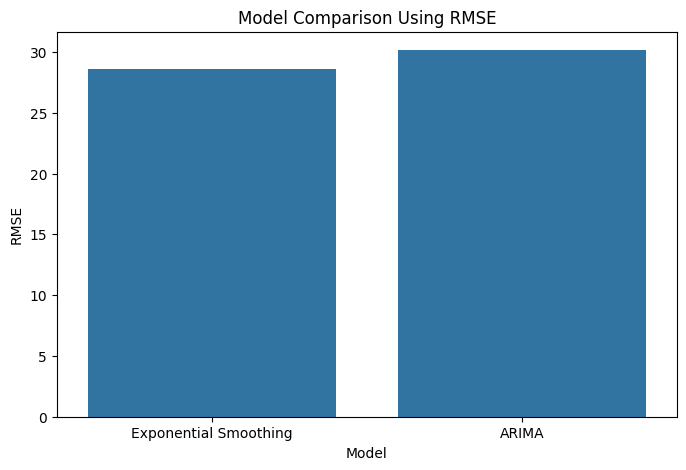

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=performance,
    x="Model",
    y="RMSE"
)

plt.title(
    "Model Comparison Using RMSE"
)

plt.savefig(
    "images/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [10]:
errors = pd.DataFrame({

    "ARIMA Errors":
    test.values - arima_forecast.values

})

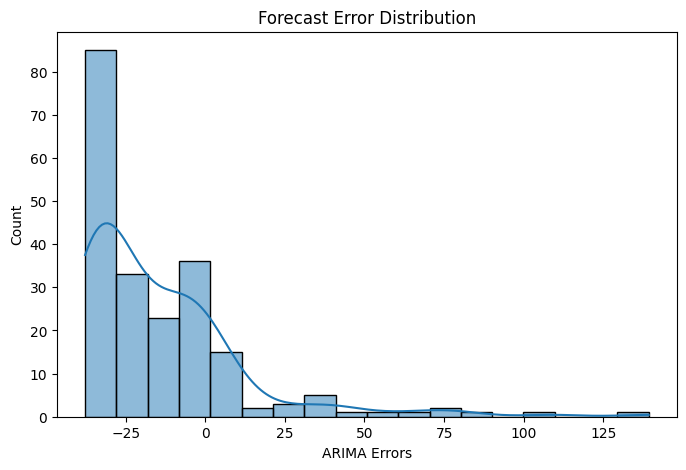

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    errors["ARIMA Errors"],
    kde=True
)

plt.title(
    "Forecast Error Distribution"
)

plt.savefig(
    "images/forecast_error_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
best_model = performance.loc[
    performance["RMSE"].idxmin()
]

best_model

,0
Model,Exponential Smoothing
MAE,16.116012
RMSE,28.572826
MAPE,NaN


In [13]:
print(
    "Best Model:",
    best_model["Model"]
)

print(
    "RMSE:",
    round(
        best_model["RMSE"],
        2
    )
)

Best Model: Exponential Smoothing
RMSE: 28.57


## Interpretation of Results

The evaluation metrics provide quantitative evidence regarding forecasting accuracy.

The model with the lowest RMSE is selected as the preferred forecasting model because it achieves the smallest average prediction error.

This model forms the forecasting engine of the Disease Outbreak Early Warning System.

## Findings

Two forecasting approaches were evaluated: Exponential Smoothing and ARIMA.

Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

The evaluation results indicated that Exponential Smoothing achieved the lowest RMSE value of approximately 28.57, outperforming the ARIMA model on the dengue forecasting task.

This suggests that recent disease observations provide stronger predictive information than the more complex autoregressive structure captured by the ARIMA specification used in this study.

Consequently, Exponential Smoothing was selected as the forecasting engine for the Disease Outbreak Early Warning System.

The results demonstrate the importance of model evaluation and show that simpler forecasting approaches can sometimes outperform more complex alternatives when modeling disease surveillance data.

In [14]:
import os

print(
    os.listdir("images")
)

['forecast_error_distribution.png', 'model_comparison.png']


In [15]:
performance.round(2)

,Model,MAE,RMSE,MAPE
0,Exponential Smoothing,16.12,28.57,NaN
1,ARIMA,24.32,30.16,NaN


In [16]:
performance.round(2).to_csv(
    "model_performance_summary.csv",
    index=False
)

print(
    "Performance summary saved."
)

Performance summary saved.
